# 📊 Praktikum Data Science - Pertemuan 9

# Algoritma Klasifikasi: Prediksi Diagnosis

👩‍🎓 Nama : Deviani Solikhah

🆔 NIM : 240401010137

🏫 Kelas : IF403

💻 Program Studi : S1 PJJ Informatika

---

# 🎯 Tujuan Praktikum

Pada praktikum ini saya mempelajari penerapan algoritma klasifikasi dalam Machine Learning menggunakan dataset **Breast Cancer Wisconsin**.Praktikum ini meliputi proses eksplorasi data (EDA), preprocessing data, pelatihan model **Logistic Regression** dan **Decision Tree**, serta evaluasi performa model menggunakan berbagai metrik evaluasi seperti Accuracy, Precision, Recall, dan F1-Score untuk mengetahui model yang memberikan hasil prediksi terbaik.

---

✅ Dataset berhasil dimuat
Shape Dataset : (569, 31)

Informasi Dataset
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error          

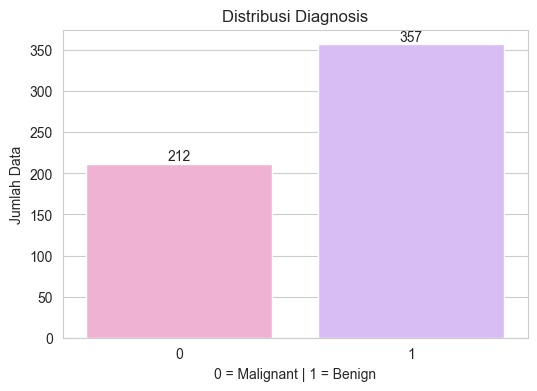

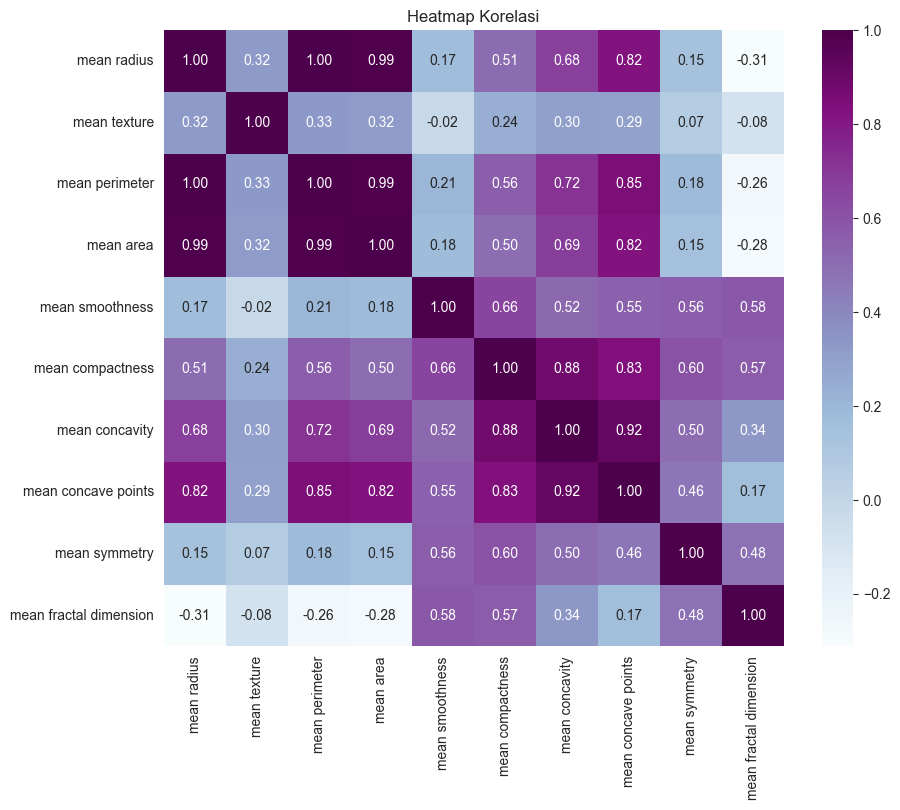

In [28]:
# 📌 Langkah 1 - Load Dataset dan Exploratory Data Analysis (EDA)

# 📚 Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Agar tampilan grafik lebih rapi
plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid") 


# 🎯 Load Dataset Breast Cancer
data = load_breast_cancer()
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
df['Diagnosis'] = data.target
print("✅ Dataset berhasil dimuat") 


# 📊 Informasi Dataset
print("Shape Dataset :", df.shape)
print("\nInformasi Dataset")
df.info() 


# 👀 Lima Data Pertama
df.head() 


# 📈 Statistik Deskriptif
df.describe().round(2) 


# 🔍 Missing Value
df.isnull().sum() 


# 📊 Distribusi Diagnosis
plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df,
    x='Diagnosis',
    hue='Diagnosis',
    palette=['#F9A8D4','#D8B4FE'],
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Distribusi Diagnosis")
plt.xlabel("0 = Malignant | 1 = Benign")
plt.ylabel("Jumlah Data")
plt.show()


# 🔥 Heatmap Korelasi
plt.figure(figsize=(10,8))
corr = df.iloc[:,:10].corr()
sns.heatmap(
    corr,
    cmap="BuPu",
    annot=True,
    fmt=".2f"
)
plt.title("Heatmap Korelasi")
plt.show() 

---
# 🔎 Analisis (What? So What? Now What?) - Langkah 1

### What?
Pada tahap ini dilakukan proses eksplorasi terhadap dataset Breast Cancer Wisconsin. Dataset berhasil dimuat dan terdiri dari sejumlah fitur numerik yang digunakan untuk membantu proses klasifikasi diagnosis kanker. Selain itu, dilakukan pengecekan struktur data, statistik deskriptif, missing value, distribusi target, serta hubungan antar fitur menggunakan heatmap korelasi.

### So What?
Hasil eksplorasi menunjukkan bahwa dataset tidak memiliki missing value sehingga data siap digunakan pada tahap berikutnya. Distribusi target juga memperlihatkan jumlah data pada masing-masing kelas, sedangkan heatmap membantu mengetahui adanya beberapa fitur yang saling berkorelasi.

### Now What?
Setelah memahami karakteristik dataset, langkah berikutnya adalah melakukan preprocessing data berupa pembagian data training dan testing serta standardisasi fitur sebelum model Machine Learning dilatih. 

--- 

In [30]:
# 📌 Langkah 2 - Data Preprocessing

# 🎯 Memisahkan Fitur dan Target
X = df.drop(columns='Diagnosis')
y = df['Diagnosis']
print("Shape X :", X.shape)
print("Shape y :", y.shape) 


# ✂️ Membagi Data Training dan Testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Jumlah Data Training :", X_train.shape)
print("Jumlah Data Testing  :", X_test.shape) 


# ⚖️ Standardisasi Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Standardisasi berhasil dilakukan") 


# 👀 Contoh Hasil Standardisasi
pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head() 

Shape X : (569, 30)
Shape y : (569,)
Jumlah Data Training : (455, 30)
Jumlah Data Testing  : (114, 30)
✅ Standardisasi berhasil dilakukan


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
1,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
2,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
3,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
4,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


---
# 🔎 Analisis (What? So What? Now What?) - Langkah 2

### What?
Pada tahap preprocessing dilakukan pemisahan antara fitur (X) dan target (y), kemudian dataset dibagi menjadi data training dan data testing dengan perbandingan 80:20. Setelah itu dilakukan standardisasi menggunakan StandardScaler agar seluruh fitur berada pada skala yang sama.

### So What?
Pembagian data bertujuan agar model dapat dilatih menggunakan data training dan dievaluasi menggunakan data testing. Standardisasi sangat penting terutama untuk algoritma seperti Logistic Regression, karena model ini sensitif terhadap perbedaan skala antar fitur.

### Now What?
Setelah data selesai dipersiapkan, langkah berikutnya adalah membangun model Logistic Regression menggunakan data hasil standardisasi, kemudian melakukan prediksi terhadap data testing. 

--- 


✅ Model Logistic Regression berhasil dilatih
Hasil Prediksi
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


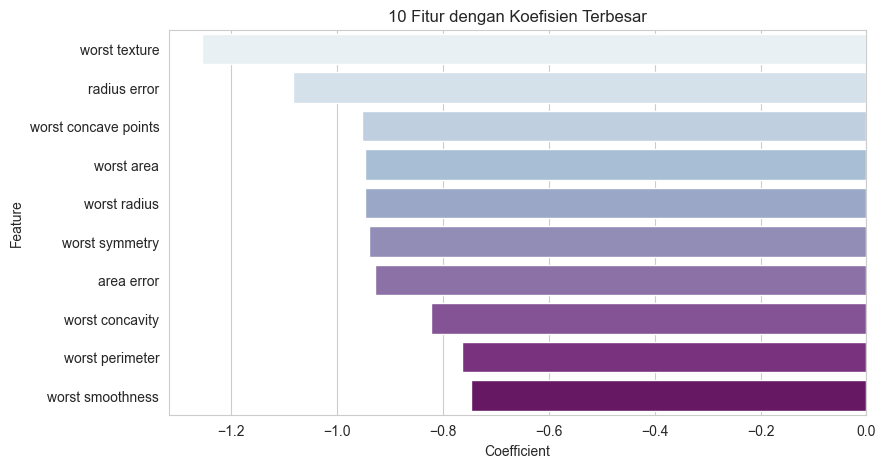

In [31]:
# 📌 Langkah 3 - Membangun Model Logistic Regression 

# 📚 Import Logistic Regression
from sklearn.linear_model import LogisticRegression


# 🤖 Melatih Model Logistic Regression
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)
logreg.fit(
    X_train_scaled,
    y_train
)
print("✅ Model Logistic Regression berhasil dilatih") 


# 🎯 Prediksi Data Testing
y_pred_log = logreg.predict(X_test_scaled)
print("Hasil Prediksi")
print(y_pred_log[:20]) 


# 📊 Koefisien Logistic Regression
coef = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':logreg.coef_[0]
})
coef = coef.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)
coef.head(10) 


# 📈 Visualisasi Koefisien
plt.figure(figsize=(9,5))
sns.barplot(
    data=coef.head(10),
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette='BuPu',
    legend=False
)
plt.title("10 Fitur dengan Koefisien Terbesar")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show() 

---
# 🔎 Analisis (What? So What? Now What?) - Langkah 3

### What?
Model Logistic Regression berhasil dilatih menggunakan data training yang telah melalui proses standardisasi. Setelah proses pelatihan selesai, model digunakan untuk memprediksi diagnosis pada data testing.

### So What?
Koefisien yang dihasilkan menunjukkan bahwa setiap fitur memiliki tingkat pengaruh yang berbeda terhadap hasil prediksi. Fitur dengan nilai koefisien paling besar memberikan kontribusi yang lebih kuat dalam menentukan apakah suatu data termasuk kategori Malignant atau Benign.

### Now What?
Tahap berikutnya adalah membangun model Decision Tree sebagai pembanding, kemudian mengevaluasi performa kedua model menggunakan metrik evaluasi klasifikasi seperti Accuracy, Precision, Recall, dan F1-Score. 

--- 


✅ Model Decision Tree berhasil dilatih
Hasil Prediksi
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


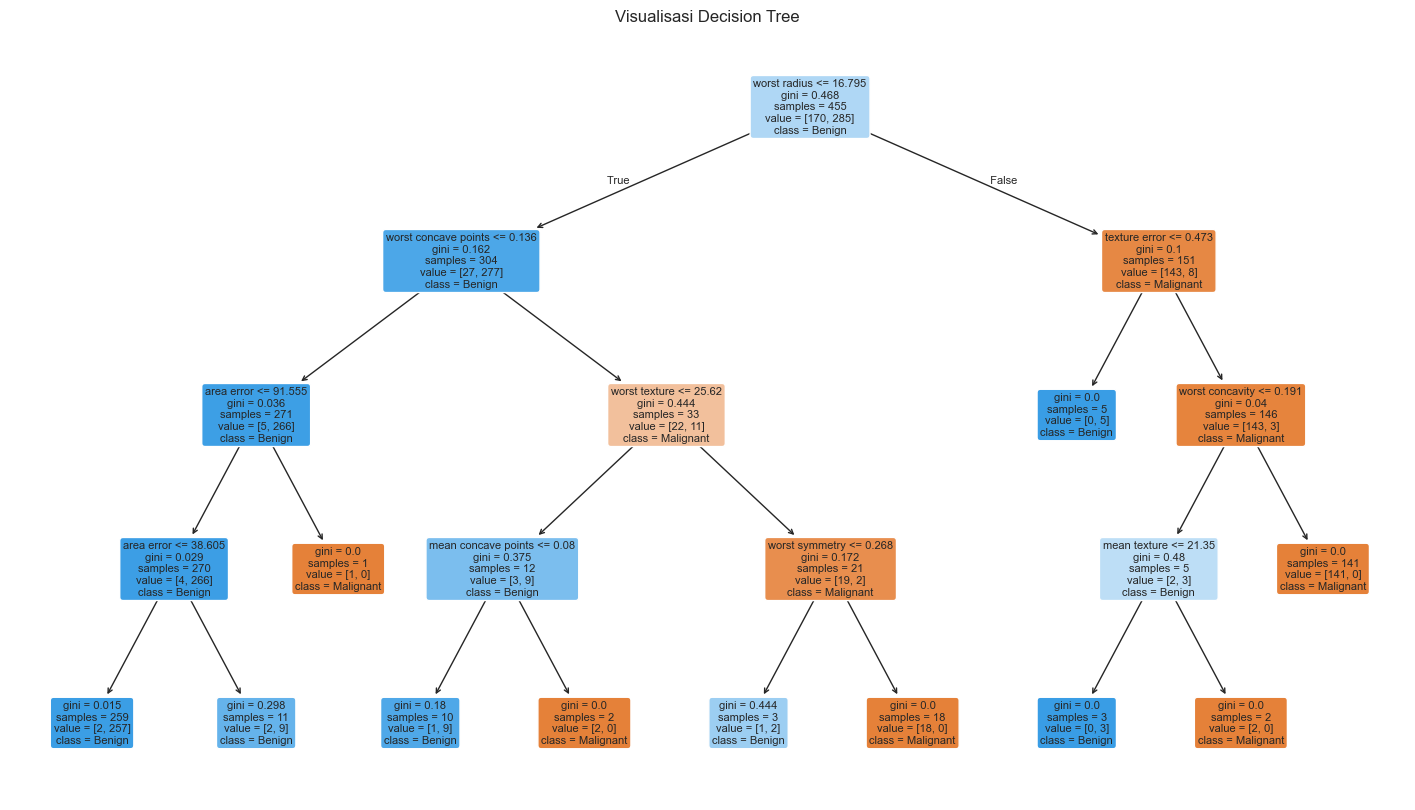

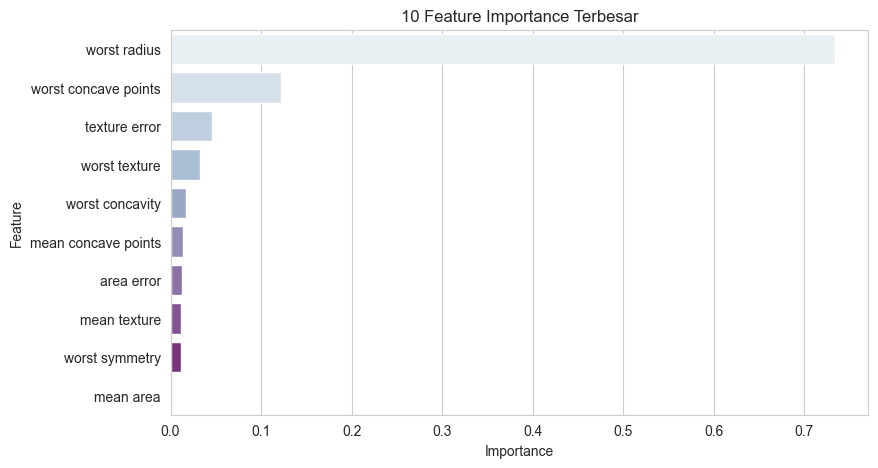

In [34]:
# 📌 Langkah 4 - Membangun Model Decision Tree 

# 📚 Import Library
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


# 🌳 Melatih Model Decision Tree
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
dt.fit(
    X_train,
    y_train
)
print("✅ Model Decision Tree berhasil dilatih") 


# 🎯 Prediksi Data Testing
y_pred_tree = dt.predict(X_test)
print("Hasil Prediksi")
print(y_pred_tree[:20]) 


# 🌳 Visualisasi Decision Tree
plt.figure(figsize=(18,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Malignant","Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visualisasi Decision Tree")
plt.show()  


# 📊 Menghitung Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10) 


# 📈 Visualisasi Feature Importance
plt.figure(figsize=(9,5))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="BuPu",
    legend=False
)
plt.title("10 Feature Importance Terbesar")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show() 

---
# 🔎 Analisis (What? So What? Now What?) - Langkah 4

### What?
Pada tahap ini model Decision Tree berhasil dilatih menggunakan data training. Setelah proses pelatihan selesai, model digunakan untuk melakukan prediksi terhadap data testing. Selain itu, dilakukan visualisasi pohon keputusan dan identifikasi fitur-fitur yang paling berpengaruh dalam proses klasifikasi.

### So What?
Visualisasi Decision Tree memperlihatkan bagaimana model mengambil keputusan berdasarkan nilai dari setiap fitur. Sementara itu, hasil Feature Importance menunjukkan bahwa tidak semua fitur memiliki pengaruh yang sama. Beberapa fitur memiliki kontribusi yang lebih besar sehingga lebih sering digunakan sebagai dasar dalam proses pemisahan data.

### Now What?
Setelah kedua model berhasil dibangun, langkah selanjutnya adalah mengevaluasi performa Logistic Regression dan Decision Tree menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, kemudian membandingkan hasilnya untuk mengetahui model yang memberikan performa terbaik.

--- 


# 📝 Kesimpulan

Berdasarkan praktikum yang telah dilakukan, proses klasifikasi pada dataset Breast Cancer Wisconsin dapat dilakukan melalui beberapa tahapan, mulai dari eksplorasi data (EDA), preprocessing, hingga pembangunan model Machine Learning menggunakan algoritma Logistic Regression dan Decision Tree. Setiap tahapan memiliki peran penting agar model dapat mempelajari pola pada data dengan baik.

Dari proses yang telah dilakukan, saya dapat memahami bahwa karakteristik data sangat memengaruhi proses pembentukan model. Selain itu, visualisasi dan analisis feature importance juga membantu mengetahui fitur-fitur yang paling berpengaruh dalam proses klasifikasi diagnosis.

Secara keseluruhan, praktikum ini memberikan pemahaman mengenai alur pembangunan model klasifikasi sebelum dilakukan proses evaluasi untuk mengetahui performa masing-masing algoritma. 